# Model genetische diversiteit

## Packages inladen

In [123]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

## Data inladen 

### Dataframe van Aquamaps en Bio-ORACLE

Deze data is afkomstig van Aquamaps

In [124]:
df_env = pd.read_csv("Data/Diversity_data_with_env.csv")
print(f"env data:             {df_env.shape}")
df_env.head()

env data:             (2452, 33)


,grid_id,long,lat,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,long_dd,lat_dd,...,Shelf,Slope,Abyssal,TidalRange,Coral,Estuary,Seamount,MPA,matched_CenterLong,matched_CenterLat
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,0.0,730.228795,263.361205,-9999.0,0.0,0.0,0,NaN,-171.75,-71.25
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-167.75,-71.25
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-164.25,-71.25
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-160.25,-71.25
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-156.25,-71.25


Deze data is afkomstig van Bio-ORACLE

In [125]:
df_biooracle = pd.read_csv("Data/Diversity_data_with_biooracle_2010.csv")
print(f"biooracle data:       {df_biooracle.shape}")
df_biooracle.head()

biooracle data:       (2452, 75)


,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,chl_max,chl_mean,chl_min,clt_max,clt_mean,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,44,11.830844,0.007171,-171.74579,-71.23536,1.987486,0.264222,0.015311,0.993542,0.681597,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,43,11.830844,0.007171,-167.88679,-71.23536,2.205368,0.278952,0.015232,0.961121,0.693978,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,44,12.650381,0.007499,-164.02779,-71.23536,1.891105,0.270836,0.015052,0.960210,0.698352,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,44,12.650381,0.007499,-160.16879,-71.23536,1.963815,0.293940,0.015424,0.962838,0.693123,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,45,12.650381,0.007499,-156.30979,-71.23536,1.956123,0.298378,0.015726,0.969080,0.688964,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


### Variabelen bekijken

In [126]:
df_biooracle.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

In [127]:
df_env.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness', 'PD',
       'co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd', 'DepthMin', 'DepthMax', 'DepthMean', 'ClimZoneCode',
       'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean',
       'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf',
       'Slope', 'Abyssal', 'TidalRange', 'Coral', 'Estuary', 'Seamount', 'MPA',
       'matched_CenterLong', 'matched_CenterLat'],
      dtype='object')

### Beide datasets samenvoegen obv locatie (longitude en latitude)


In [128]:
df_merge = pd.merge(df_env, df_biooracle, on = ["long_deg", "lat_deg"], how = "inner")
print(f"merged data:             {df_merge.shape}")
df_merge.head()

merged data:             (2452, 106)


,grid_id,long,lat,marine_species_richness_x,PD_x,co1_genetic_diversity_mean_x,long_deg,lat_deg,long_dd,lat_dd,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [129]:
df_merge.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness_x', 'PD_x',
       'co1_genetic_diversity_mean_x', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd',
       ...
       'terrain_characteristics_bea_min', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_ltmax', 'T_ltmin', 'T_max', 'T_mean', 'T_min', 'T_range'],
      dtype='object', length=106)

 data verwijderen die onnodig is: meerdere keren coördinaten, andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [130]:
cols_to_drop = (df_merge.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["PD_x", "PD_y","marine_species_richness_x", "marine_species_richness_y", "grid_id", "long", "lat", "long_dd", "lat_dd","MPA"])
df_merge = df_merge.drop(cols_to_drop, axis = 1)
df_merge.head()

,co1_genetic_diversity_mean_x,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,0.007171,-171.74579,-71.23536,3998,SP,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,0.007171,-167.88679,-71.23536,4079,SP,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,0.007499,-164.02779,-71.23536,4185,SP,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,0.007499,-160.16879,-71.23536,4231,SP,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,0.007499,-156.30979,-71.23536,4322,SP,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Categorische variabele encoderen als numerieke variabele

In [131]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df_merge.select_dtypes(include="object").columns

for col in categorical_cols:
    df_merge[col] = le.fit_transform(df_merge[col].astype(str))


In [132]:
df_merge.head()

,co1_genetic_diversity_mean_x,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,0.007171,-171.74579,-71.23536,3998,5,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,0.007171,-167.88679,-71.23536,4079,5,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,0.007499,-164.02779,-71.23536,4185,5,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,0.007499,-160.16879,-71.23536,4231,5,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,0.007499,-156.30979,-71.23536,4322,5,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Dubbele kolommen verwijderen

In [133]:
df_merge = df_merge.T.drop_duplicates().T
df_merge = df_merge.rename(columns={"co1_genetic_diversity_mean_x": "co1_genetic_diversity_mean"})
df_merge.head()

,co1_genetic_diversity_mean,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,0.007171,-171.74579,-71.23536,3998.0,5.0,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,0.007171,-167.88679,-71.23536,4079.0,5.0,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,0.007499,-164.02779,-71.23536,4185.0,5.0,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,0.007499,-160.16879,-71.23536,4231.0,5.0,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,0.007499,-156.30979,-71.23536,4322.0,5.0,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


In [134]:
df_merge.columns

Index(['co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'DepthMean',
       'ClimZoneCode', 'SSTAnMean', 'SBTAnMean', 'SalinityMean',
       'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean',
       'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary', 'Seamount',
       'matched_CenterLong', 'matched_CenterLat', 'chl_mean', 'clt_mean',
       'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

## Data exploratie

### Distributie van de doelvariabele

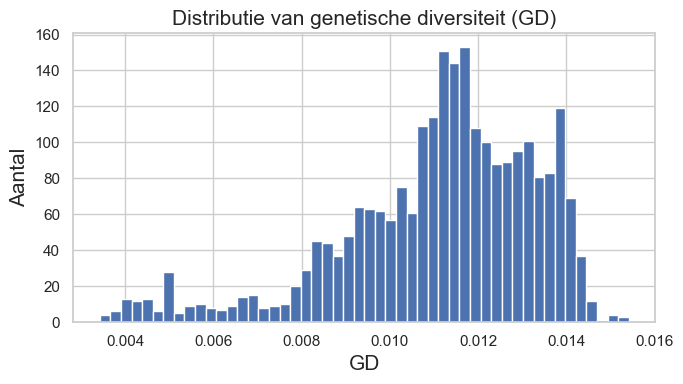

In [135]:
target = "co1_genetic_diversity_mean"
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_merge[target], bins=50, edgecolor="white")
ax.set_xlabel("GD", fontsize = 15)
ax.set_ylabel("Aantal", fontsize = 15)
ax.set_title("Distributie van genetische diversiteit (GD)", fontsize = 15)
plt.tight_layout()
plt.show()

Visualisatie doelvariabele

In [136]:
import plotly.express as px
import plotly.io as pio

fig = px.scatter_geo(
    df_merge,
    lat="lat_deg",
    lon="long_deg",
    color="co1_genetic_diversity_mean",
    hover_name="co1_genetic_diversity_mean",
    projection="natural earth",
    range_color=(0,0.017)
)

fig.update_layout(
    title="Genetische diversiteit (GD)",
    title_font=dict(size=32)
)

fig.update_coloraxes(
    colorbar=dict(
        title=dict(text="GD", font=dict(size=24)),
        tickfont=dict(size=18)
    )
)

fig.show()

### Correlatie berekenen
Variabelen t.o.v. target

In [ ]:
corr_to_target = df_merge.corr(method = "pearson")[target].drop(labels = [target]) #correlatie berekenen van alle variabelen tov target en correlatie target met zichzelf laten vallen (is toch gelijk aan 1)
top = corr_to_target.reindex(corr_to_target.abs().sort_values(ascending=False).index) #sorteer van hoog naar laag
top.head(10)

tas_mean       0.828179
OxyMean       -0.805125
o2_mean       -0.801597
SSTAnMean      0.796844
T_mean         0.796517
clt_mean      -0.690056
par_mean       0.664754
IceConAnn     -0.647700
po4_mean      -0.646589
siconc_mean   -0.641711
Name: co1_genetic_diversity_mean, dtype: float64

variabelen t.o.v. elkaar

In [ ]:
corr = df_merge.corr(numeric_only=True)

# corr omzetten naar lijst van paren
corr_pairs = corr.abs().unstack()

# zelf-correlaties verwijderen
corr_pairs = corr_pairs[corr_pairs < 1]

# top 10
top_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates().head(10)

print(top_pairs)

matched_CenterLong  long_deg             0.999999
lat_deg             matched_CenterLat    0.999993
SSTAnMean           T_mean               0.999700
o2_mean             OxyMean              0.996973
IceConAnn           siconc_mean          0.992688
tas_mean            T_mean               0.988904
                    SSTAnMean            0.988185
T_mean              o2_mean              0.984634
o2_mean             SSTAnMean            0.984594
T_mean              OxyMean              0.983702
dtype: float64


## Volledig model

Dit model bevat data afkomstig van Aquamaps en Bio-ORACLE

### Target en variabelen selecteren

In [ ]:
target = "co1_genetic_diversity_mean" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols = df_merge.columns.drop(["long_deg", "lat_deg", target]).tolist()

print(feature_cols)

['DepthMean', 'ClimZoneCode', 'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary', 'Seamount', 'matched_CenterLong', 'matched_CenterLat', 'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean', 'terrain_characteristics_rug', 'terrain_characteristics_slope', 'terrain_characteristics_topo', 'T_mean']


In [ ]:
df_model = df_merge[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df_model.shape}")
df_model.describe()

Shape before cleaning: (2452, 44)


,co1_genetic_diversity_mean,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
count,2452.000000,2452.000000,2452.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,...,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2217.000000
mean,0.011101,3395.364192,4.914763,16.134410,2.069516,34.374631,34.574813,4.597464,0.054981,257.412446,...,0.059461,0.070197,14.698095,14.624145,183.500427,-3748.862966,94.427332,1.179893e+00,-2.727722,16.382824
std,0.002254,1807.135985,2.244826,10.626096,4.586234,1.838647,1.254989,5.905518,0.162398,54.275344,...,0.173575,0.215610,26.476457,11.465120,104.334155,1538.097895,106.862539,1.406274e+00,76.048905,10.565343
min,0.003430,0.000000,0.000000,-1.790485,-1.731767,4.524624,5.264678,0.096000,0.000000,196.910355,...,0.000000,0.000000,0.656868,-16.241398,0.182399,-7138.611328,0.000000,2.484808e-17,-658.309052,-1.838033
25%,0.009949,2556.000000,4.000000,6.128384,0.496306,33.835644,34.677283,1.642750,0.000000,207.841774,...,0.000000,0.000000,1.594731,5.300397,93.788117,-4841.555664,30.402771,3.307500e-01,-28.128448,6.396754
50%,0.011438,3944.000000,5.000000,18.972795,1.054664,34.463772,34.698887,2.995500,0.000000,236.162773,...,0.000000,0.000000,2.670603,17.737980,184.875910,-4115.527832,62.715210,7.419182e-01,-1.149323,19.306662
75%,0.012741,4753.250000,7.000000,26.209159,1.656099,35.316861,34.722000,5.623750,0.000000,308.180664,...,0.000000,0.000000,13.881882,25.288107,274.005903,-3187.027832,117.663208,1.471722e+00,19.500183,26.387225
max,0.015409,7660.000000,8.000000,29.790718,29.696379,38.469193,40.475456,99.214002,0.965107,394.526001,...,0.963429,1.794409,121.972284,28.490869,359.858364,0.000000,1098.482654,1.466965e+01,748.565994,30.261832


### Ontbrekende waarden verwijderen

In [ ]:
df_model.replace(-9999.0, np.nan, inplace=True)
df_model.replace(-9999, np.nan, inplace=True)

missing = df_model.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_model.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_model.shape}")

Missende waarden per kolom:

SSTAnMean                           172
SBTAnMean                           172
SalinityMean                        172
SalinityBMean                       172
PrimProdMean                        172
IceConAnn                           172
OxyMean                             172
OxyBMean                            172
chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean    

### Data splitten in training en test set

In [ ]:
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Training set: 1760
Test set: 441


### Fitten van een Random Forest model op training set

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=1,
    max_features = 0.5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Hyperparameters optimaliseren

De bekomen hyperparameters in model hierboven gebruiken

 Code momenteel als markdown 

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 800}

### Evalueren van rf op training en test set

Moet op beide goed zijn anders is het overgefit op training set

In [ ]:
y_pred = rf.predict(X_test)

r2_train = rf.score(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train R²: {r2_train:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"\nTrain-test gap: {r2_train - r2:.4f}")

Train R²: 0.9923
Test R²: 0.9445
RMSE: 0.0005
MAE: 0.0004

Train-test gap: 0.0478


### Visualiseren resultaten

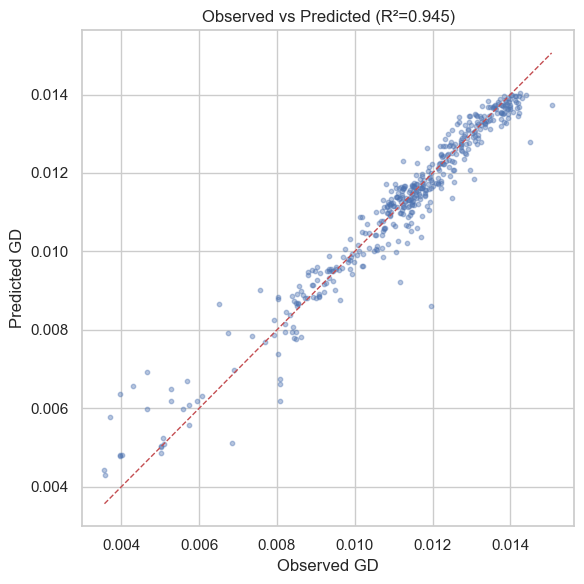

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test, y_pred, alpha=0.4, s = 10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Observed GD")
ax.set_ylabel("Predicted GD")
ax.set_title(f"Observed vs Predicted (R²={r2:.3f})")
plt.tight_layout()
plt.show()

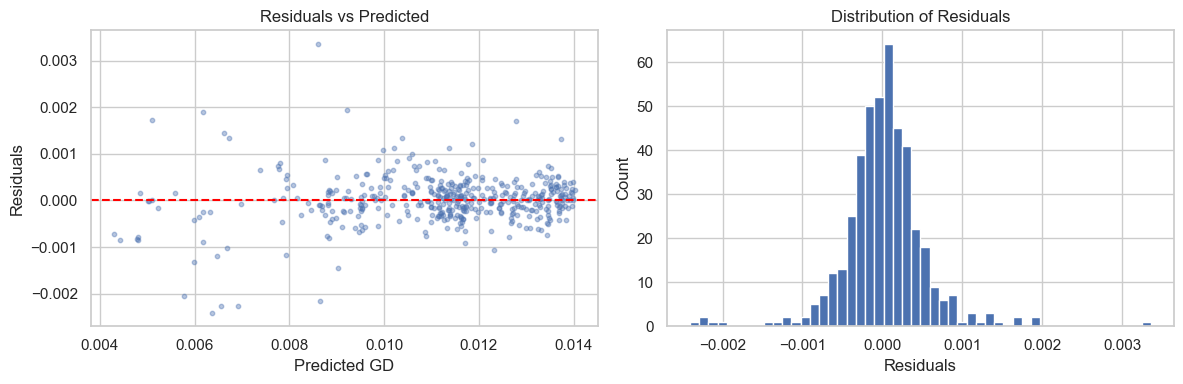

In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred, residuals, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted GD")
axes[0].set_ylabel("Residuals") 
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuals") 
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Feature importances van gefitte rf

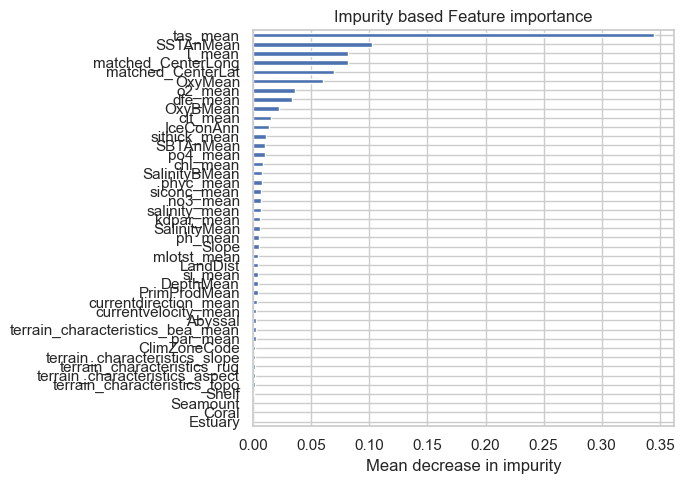

In [ ]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity based Feature importance")
plt.tight_layout()
plt.show()

### Spatiale crossvalidatie

In [ ]:
lat = df_merge.loc[df_model.index, "lat_deg"]
lon = df_merge.loc[df_model.index, "long_deg"]
lat_bin = pd.cut(lat, bins = np.arange(-90, 91,10), labels = False)
lon_bin = pd.cut(lon, bins = np.arange(-180, 181,10), labels = False)
spatial_blocks = lat_bin.astype(str) + "_" + lon_bin.astype(str)

print(f"\nSpatial blocks (10°x10° grid): {spatial_blocks.nunique()} unique blocks")

gkf = GroupKFold(n_splits=5)
spatial_cv = cross_val_score(
    rf, X, y, cv = gkf, groups = spatial_blocks, scoring= "r2", n_jobs = 1,
)
print("Spatial 5 fold VC R² scores:", np.round(spatial_cv, 4))
print(f"Mean R²: {spatial_cv.mean():.4f} ± {spatial_cv.std():.4f}")


Spatial blocks (10°x10° grid): 422 unique blocks
Spatial 5 fold VC R² scores: [0.9537 0.9409 0.9303 0.9219 0.9099]
Mean R²: 0.9314 ± 0.0151


## Model met minder variabelen

Dit model bevat enkel variabelen van Bio-ORACLE. Daarnaast worden de variabelen die niet beschikbaar zijn in de toekomst ook verwijderd. Op dit model wordt ook dimensionaliteitsreductie uitgevoerd.

### Dataframe met enkel Bio-ORACLE

In [5]:
df_bio = df_biooracle
df_bio.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

Data verwijderen die onnodig is: andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [6]:
cols_to_drop = (df_bio.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["PD", "marine_species_richness"])
df_bio = df_bio.drop(cols_to_drop, axis = 1)

df_bio.columns

Index(['co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'chl_mean',
       'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

Variabelen verwijderen die niet beschikbaar zijn in de toekomst

In [7]:
cols_to_drop = (df_bio.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["kdpar_mean", "par_mean", "terrain_characteristics_aspect", "terrain_characteristics_bea_mean", "terrain_characteristics_rug", "terrain_characteristics_slope", "terrain_characteristics_topo"])
df_bio = df_bio.drop(cols_to_drop, axis = 1)

df_bio.columns

Index(['co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'chl_mean',
       'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'mlotst_mean', 'no3_mean', 'o2_mean', 'phyc_mean', 'ph_mean',
       'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean',
       'tas_mean', 'T_mean'],
      dtype='object')

In [8]:
target_red = "co1_genetic_diversity_mean" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols_red = df_bio.columns.drop(["long_deg", "lat_deg", "co1_genetic_diversity_mean"]).tolist()

df_red = df_bio[[target_red] + feature_cols_red].copy()
print(f"Shape before cleaning: {df_red.shape}")
df_red.describe()

Shape before cleaning: (2452, 18)


,co1_genetic_diversity_mean,chl_mean,clt_mean,currentdirection_mean,currentvelocity_mean,dfe_mean,mlotst_mean,no3_mean,o2_mean,phyc_mean,ph_mean,po4_mean,salinity_mean,siconc_mean,sithick_mean,si_mean,tas_mean,T_mean
count,2452.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000
mean,0.011101,0.259398,0.447101,152.689401,0.096974,0.000404,48.266381,7.874852,257.423756,1.538574,8.043805,0.673196,34.520979,0.059461,0.070197,14.698095,14.624145,16.382824
std,0.002254,0.215264,0.186835,80.485733,0.096603,0.000829,28.577804,10.287690,53.447055,0.745757,0.025790,0.700528,1.583589,0.173575,0.215610,26.476457,11.465120,10.565343
min,0.003430,0.043151,0.027449,8.444567,0.001367,0.000005,6.990705,0.000422,197.984285,0.554283,7.793579,0.000169,3.213432,0.000000,0.000000,0.656868,-16.241398,-1.838033
25%,0.009949,0.105136,0.271776,74.841409,0.036148,0.000070,29.868310,0.020503,208.600594,1.213635,8.033113,0.090502,33.910668,0.000000,0.000000,1.594731,5.300397,6.396754
50%,0.011438,0.244400,0.450085,138.466769,0.068392,0.000143,41.403713,2.020931,235.609703,1.444429,8.044218,0.381472,34.541424,0.000000,0.000000,2.670603,17.737980,19.306662
75%,0.012741,0.346993,0.613930,233.689689,0.125637,0.000330,56.961308,15.241677,305.790494,1.622265,8.056951,1.198416,35.364977,0.000000,0.000000,13.881882,25.288107,26.387225
max,0.015409,3.750575,0.785068,315.692114,1.121662,0.009292,199.046201,36.047286,387.724233,13.682373,8.141021,2.234311,38.747336,0.963429,1.794409,121.972284,28.490869,30.261832


Hier nog eens opnieuw de missende waarden verwijderen, want df is weer gemaakt op basis van de kolommen waar die waarden nog niet waren verwijderd. 

In [9]:
df_red.replace(-9999.0, np.nan, inplace=True)
df_red.replace(-9999, np.nan, inplace=True)

missing = df_red.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_red.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_red.shape}")

Missende waarden per kolom:

chl_mean                 235
clt_mean                 235
currentdirection_mean    235
currentvelocity_mean     235
dfe_mean                 235
mlotst_mean              235
no3_mean                 235
o2_mean                  235
phyc_mean                235
ph_mean                  235
po4_mean                 235
salinity_mean            235
siconc_mean              235
sithick_mean             235
si_mean                  235
tas_mean                 235
T_mean                   235
dtype: int64

Shape after dropping rows with NaN: (2217, 18)


In [10]:
print(df_red.isna().sum().sort_values(ascending=False).head(10))

co1_genetic_diversity_mean    0
chl_mean                      0
tas_mean                      0
si_mean                       0
sithick_mean                  0
siconc_mean                   0
salinity_mean                 0
po4_mean                      0
ph_mean                       0
phyc_mean                     0
dtype: int64


In [11]:
X_red = df_red[feature_cols_red]
y_red = df_red[target_red]

In [12]:
X_red.columns

Index(['chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean',
       'dfe_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'phyc_mean',
       'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean',
       'si_mean', 'tas_mean', 'T_mean'],
      dtype='object')

### Recursive feature elimination 


RMSE en spatiale cross validatie

In [13]:
# Spatial blocks aanmaken op basis van df_bio
lat_bio = df_bio.loc[df_red.index, "lat_deg"]
lon_bio = df_bio.loc[df_red.index, "long_deg"]
lat_bin_bio = pd.cut(lat_bio, bins=np.arange(-90, 91, 10), labels=False)
lon_bin_bio = pd.cut(lon_bio, bins=np.arange(-180, 181, 10), labels=False)
spatial_blocks_red = lat_bin_bio.astype(str) + "_" + lon_bin_bio.astype(str)

print(f"Spatial blocks (10°x10° grid): {spatial_blocks_red.nunique()} unique blocks")

Spatial blocks (10°x10° grid): 424 unique blocks


Als markdown

from sklearn.feature_selection import RFECV

#### Random Forest
estimator = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

#### RFECV met spatial CV + RMSE
selector = RFECV(
    estimator,
    step=1,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

selector.fit(X_red, y_red, groups=spatial_blocks_red)

print(f"Optimal number of features: {selector.n_features_}")

selected_features_RFECV = X_red.columns[selector.support_]
print("Selected features:", list(selected_features_RFECV))

### Dataset met geselecteerde features

In [14]:
selected_features_RFECV = [
'chl_mean', 
'clt_mean',
'dfe_mean',
'mlotst_mean',
'no3_mean',
'o2_mean', 
'phyc_mean', 
'ph_mean', 
'po4_mean',
'salinity_mean',
'tas_mean', 
'T_mean'
]

### Data splitten in training en test set

In [15]:
X_selected = X_red[selected_features_RFECV]
y_selected = y_red

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y_selected, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train_selected.shape[0]}")
print(f"Test set: {X_test_selected.shape[0]}")

Training set: 1773
Test set: 444


### Fitten van een rf model op training set met enkel geselecteerde features

In [16]:

rf_selected_RFECV = RandomForestRegressor(
    n_estimators=500,
    max_depth=30,
    min_samples_leaf=1,
    max_features=0.5,
    random_state=42,
    n_jobs=-1,
)

rf_selected_RFECV.fit(X_train_selected, y_train_selected)

# Feature importances
imp = pd.Series(
    rf_selected_RFECV.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

phyc_mean        0.018360
chl_mean         0.019526
mlotst_mean      0.020491
ph_mean          0.023053
no3_mean         0.036979
po4_mean         0.040701
salinity_mean    0.049543
dfe_mean         0.060914
clt_mean         0.068870
o2_mean          0.111229
T_mean           0.167728
tas_mean         0.382605
dtype: float64


### Hyperparameters optimaliseren

In markdown

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

lat_train = df_bio.loc[X_train_selected.index, "lat_deg"]
lon_train = df_bio.loc[X_train_selected.index, "long_deg"]
lat_bin_train = pd.cut(lat_train, bins=np.arange(-90, 91, 10), labels=False)
lon_bin_train = pd.cut(lon_train, bins=np.arange(-180, 181, 10), labels=False)
spatial_blocks_train = lat_bin_train.astype(str) + "_" + lon_bin_train.astype(str)

rf= RandomForestRegressor(random_state=42)

# de hyperparameters optimaliseren 
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=gkf,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_selected, y_train_selected, groups=spatial_blocks_train)

print(grid.best_params_)

resultaten: {'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 500}

### Evalueren rf op training en test set

In [17]:
y_pred_sel = rf_selected_RFECV.predict(X_test_selected)

r2_train_sel = rf_selected_RFECV.score(X_train_selected, y_train_selected)
rmse_sel = np.sqrt(mean_squared_error(y_test_selected, y_pred_sel))
mae_sel = mean_absolute_error(y_test_selected, y_pred_sel)
r2_sel = r2_score(y_test_selected, y_pred_sel)

print(f"Train R²: {r2_train_sel:.4f}")
print(f"Test R²: {r2_sel:.4f}")
print(f"RMSE: {rmse_sel:.4f}")
print(f"MAE: {mae_sel:.4f}")
print(f"\nTrain-test gap: {r2_train_sel - r2_sel:.4f}")

Train R²: 0.9876
Test R²: 0.9191
RMSE: 0.0006
MAE: 0.0004

Train-test gap: 0.0685


### Visualisatie 

NameError: name 'r2' is not defined

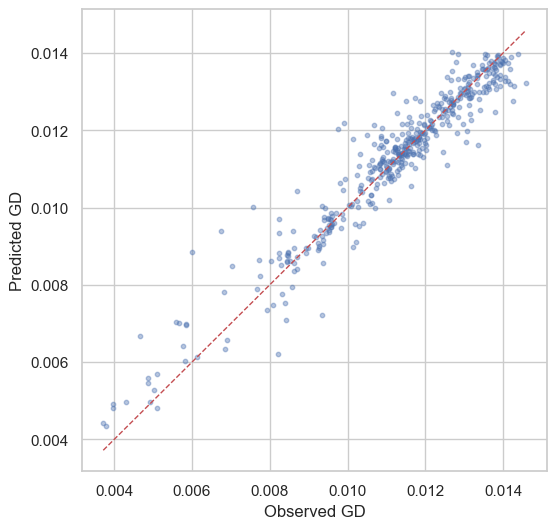

In [19]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test_selected, y_pred_sel, alpha=0.4, s = 10)
lims = [min(y_test_selected.min(), y_pred_sel.min()), max(y_test_selected.max(), y_pred_sel.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Observed GD")
ax.set_ylabel("Predicted GD")
ax.set_title(f"Observed vs Predicted (R²={r2:.3f})")
plt.tight_layout()
plt.show()

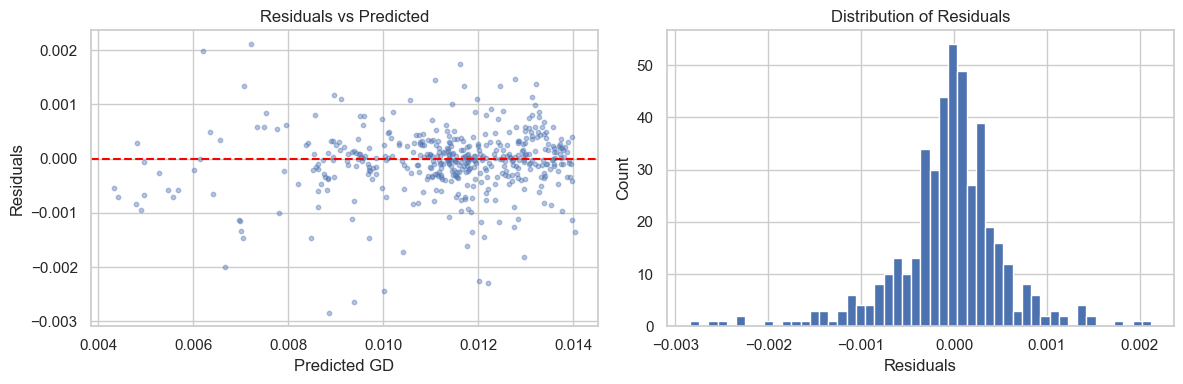

In [20]:
residuals_red = y_test_selected - y_pred_sel

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred_sel, residuals_red, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted GD")
axes[0].set_ylabel("Residuals") 
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals_red, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuals") 
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Feature importance

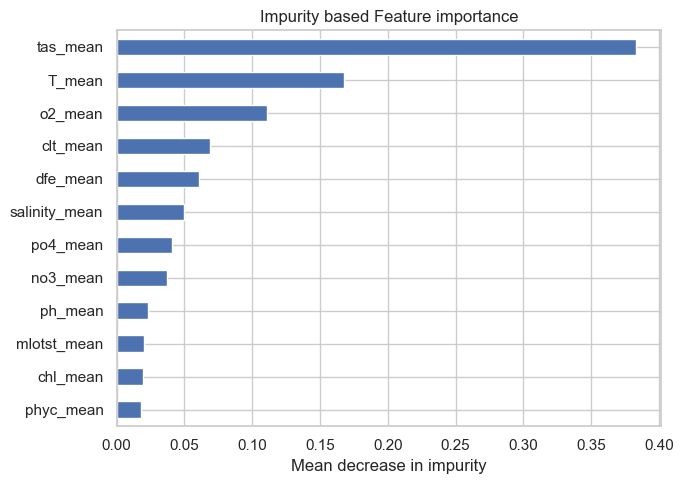

In [21]:
imp_red = pd.Series(rf_selected_RFECV.feature_importances_, index=selected_features_RFECV).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp_red.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity based Feature importance")
plt.tight_layout()
plt.show()

## Definitieve model
Nu weten we adhv het model gemaakt van train en test set dat het een goeie performantie heeft. Nu kunnen we het model opnieuw met alle data maken(niet meer opgesplits in train en test). Op die manier gaat er geen informatie verloren.

In [22]:

rf_selected_RFECV.fit(X_selected, y_selected)

# Feature importances
imp = pd.Series(
    rf_selected_RFECV.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

phyc_mean        0.018391
mlotst_mean      0.021731
chl_mean         0.022023
ph_mean          0.022200
no3_mean         0.033869
po4_mean         0.034891
salinity_mean    0.049170
dfe_mean         0.064772
clt_mean         0.066835
o2_mean          0.116091
T_mean           0.167338
tas_mean         0.382689
dtype: float64


## Toekomst

### Toekomstige data inladen

In [137]:
# 50-60
SSP119_50_60 = pd.read_csv('Data/2050-60_SSP119.csv')
SSP245_50_60 = pd.read_csv('Data/2050-60_SSP245.csv')
SSP585_50_60 = pd.read_csv('Data/2050-60_SSP585.csv')
SSP119_50_60.columns

#90-100
SSP119_90_100 = pd.read_csv('Data/2090-2100_SSP119.csv')
SSP245_90_100 = pd.read_csv('Data/2090-2100_SSP245.csv')
SSP585_90_100 = pd.read_csv('Data/2090-2100_SSP585.csv')
SSP119_90_100.columns


Index(['Unnamed: 0', 'chl_mean', 'clt_mean', 'dfe_mean', 'mlotst_mean',
       'no3_mean', 'o2_mean', 'phyc_mean', 'ph_mean', 'po4_mean',
       'siconc_mean', 'sithick_mean', 'si_mean', 'salinity_mean',
       'currentdirection_mean', 'currentvelocity_mean', 'tas_mean', 'T_mean',
       'long_deg', 'lat_deg'],
      dtype='object')

De kolommen selecteren van de selected features

In [145]:
# 50-60
GD_SSP119_50_60 = SSP119_50_60[['long_deg', 'lat_deg'] + selected_features_RFECV]
GD_SSP245_50_60 = SSP245_50_60[['long_deg', 'lat_deg'] + selected_features_RFECV]
GD_SSP585_50_60 = SSP585_50_60[['long_deg', 'lat_deg'] + selected_features_RFECV]


#90-100
GD_SSP119_90_100 = SSP119_90_100[['long_deg', 'lat_deg'] + selected_features_RFECV]
GD_SSP245_90_100 = SSP245_90_100[['long_deg', 'lat_deg'] + selected_features_RFECV]
GD_SSP585_90_100 = SSP585_90_100[['long_deg', 'lat_deg'] + selected_features_RFECV]


### Toekomst voorspellingen SSP119

#### Voorspelling jaren 50-60

In [146]:
X_SSP119_50_60 = GD_SSP119_50_60[selected_features_RFECV] 
y_SSP119_50_60 = rf_selected_RFECV.predict(X_SSP119_50_60)

GD_SSP119_50_60["GD"] =  y_SSP119_50_60


C:\Users\katom\AppData\Local\Temp\ipykernel_14972\1687512621.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

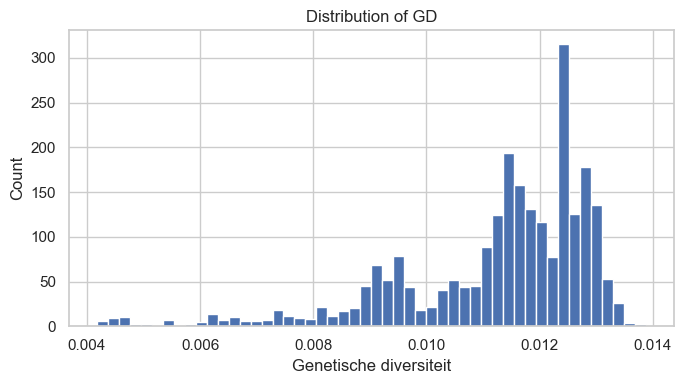

In [147]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(GD_SSP119_50_60["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

Kaart plotten

In [148]:
import plotly.express as px
import plotly.io as pio

In [149]:
fig_GD_SSP119_50_60 = px.scatter_geo(
    GD_SSP119_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title= "Genetische diversiteit volgens SSP119 (2050-2060)",
    range_color = (0, 0.017)
)

fig_GD_SSP119_50_60.update_layout(
    title=dict(
        font=dict(size=32)
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)


fig_GD_SSP119_50_60.show()

Kaart met verschil plotten

In [150]:
GD_SSP119_50_60["Relatief verschil"] = (GD_SSP119_50_60["GD"] - df_bio["co1_genetic_diversity_mean"])/df_bio["co1_genetic_diversity_mean"]
fig_GD_SSP119_50_60_verschil = px.scatter_geo(
    GD_SSP119_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil in genetische diversiteit (SSP119 (2050-2060) vs Huidige situatie)"
)

fig_GD_SSP119_50_60_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP119_50_60_verschil.show()

C:\Users\katom\AppData\Local\Temp\ipykernel_14972\3772720605.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Voorspelling jaren 90-100

In [151]:
X_SSP119_90_100 = GD_SSP119_90_100[selected_features_RFECV] 
y_SSP119_90_100 = rf_selected_RFECV.predict(X_SSP119_90_100)

GD_SSP119_90_100["GD"] =  y_SSP119_90_100


C:\Users\katom\AppData\Local\Temp\ipykernel_14972\2112110967.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

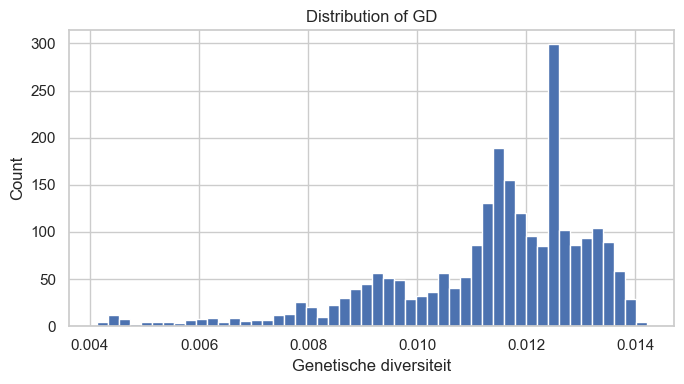

In [152]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(GD_SSP119_90_100["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

Kaart plotten

In [153]:
fig_GD_SSP119_90_100 = px.scatter_geo(
    GD_SSP119_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit volgens SSP119 (2090-2100)",
    range_color = (0, 0.017)
)

fig_GD_SSP119_90_100.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP119_90_100.show()

Kaart met verschil plotten

In [155]:
GD_SSP119_90_100["Relatief verschil"] = (GD_SSP119_90_100["GD"] - df_bio["co1_genetic_diversity_mean"])/df_bio["co1_genetic_diversity_mean"]
fig_GD_SSP119_90_100_verschil = px.scatter_geo(
    GD_SSP119_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil in genetische diversiteit (SSP119 (2090-2100) vs Huidige situatie)"
)

fig_GD_SSP119_90_100_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP119_90_100_verschil.show()

C:\Users\katom\AppData\Local\Temp\ipykernel_14972\3716025649.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Toekomst voorspellingen SSP245

#### Voorspelling jaren 50-60

In [156]:
X_SSP245_50_60 = GD_SSP245_50_60[selected_features_RFECV] 
y_SSP245_50_60 = rf_selected_RFECV.predict(X_SSP245_50_60)

GD_SSP245_50_60["GD"] =  y_SSP245_50_60


C:\Users\katom\AppData\Local\Temp\ipykernel_14972\868913061.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

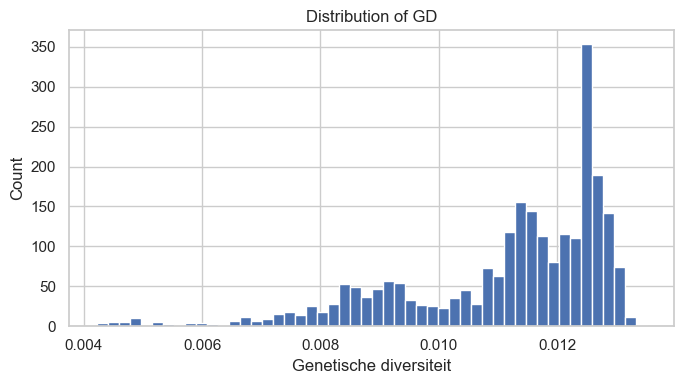

In [157]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(GD_SSP245_50_60["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

Kaart plotten

In [158]:
fig_GD_SSP245_50_60 = px.scatter_geo(
    GD_SSP245_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit volgens SSP245 (2050-2060)",
    range_color = (0, 0.017)
)

fig_GD_SSP245_50_60.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP245_50_60.show()

Kaart met verschil plotten

In [160]:
GD_SSP245_50_60["Relatief verschil"] = (GD_SSP245_50_60["GD"] - df_bio["co1_genetic_diversity_mean"])/df_bio["co1_genetic_diversity_mean"]
fig_GD_SSP245_50_60_verschil = px.scatter_geo(
    GD_SSP245_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil in genetische diversiteit (SSP245 (2050-2060) vs Huidige situatie)"
)

fig_GD_SSP245_50_60_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP245_50_60_verschil.show()

C:\Users\katom\AppData\Local\Temp\ipykernel_14972\1725967168.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Voorspelling jaren 90-100

In [161]:
X_SSP245_90_100 = GD_SSP245_90_100[selected_features_RFECV] 
y_SSP245_90_100 = rf_selected_RFECV.predict(X_SSP245_90_100)

GD_SSP245_90_100["GD"] =  y_SSP245_90_100


C:\Users\katom\AppData\Local\Temp\ipykernel_14972\751315272.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

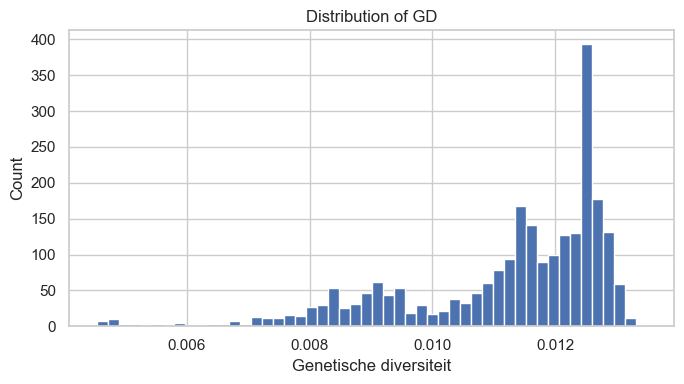

In [162]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(GD_SSP245_90_100["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

Kaart plotten

In [163]:
fig_GD_SSP245_90_100 = px.scatter_geo(
    GD_SSP245_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit volgens SSP245 (2090-2100)",
    range_color = (0, 0.017)
)

fig_GD_SSP245_90_100.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP245_90_100.show()

Kaart met verschil plotten

In [165]:
GD_SSP245_90_100["Relatief verschil"] = (GD_SSP245_90_100["GD"] - df_bio["co1_genetic_diversity_mean"])/df_bio["co1_genetic_diversity_mean"]
fig_GD_SSP245_90_100_verschil = px.scatter_geo(
    GD_SSP245_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil in genetische diversiteit (SSP245 (2090-2100) vs Huidige situatie)"
)

fig_GD_SSP245_90_100_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP245_90_100_verschil.show()

C:\Users\katom\AppData\Local\Temp\ipykernel_14972\2194987710.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Toekomst voorspellingen SSP585

#### Voorspelling jaren 50-60

In [166]:
X_SSP585_50_60 = GD_SSP585_50_60[selected_features_RFECV] 
y_SSP585_50_60 = rf_selected_RFECV.predict(X_SSP585_50_60)

GD_SSP585_50_60["GD"] =  y_SSP585_50_60

C:\Users\katom\AppData\Local\Temp\ipykernel_14972\3470677904.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

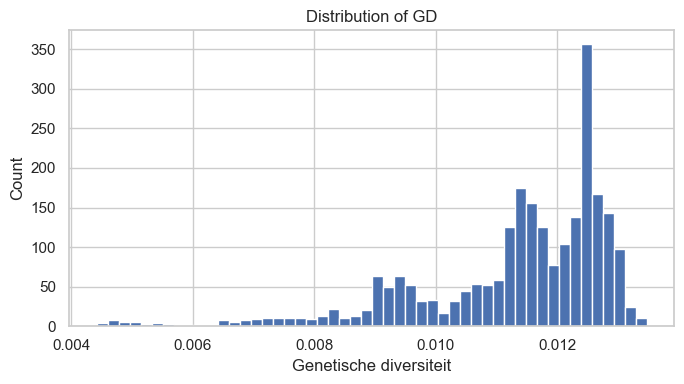

In [167]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(GD_SSP585_50_60["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

Kaart plotten

In [168]:
fig_GD_SSP585_50_60 = px.scatter_geo(
    GD_SSP585_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit volgens SSP585 (2050-2060)",
    range_color = (0, 0.017)
)
fig_GD_SSP585_50_60.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP585_50_60.show()

Kaart met verschil plotten

In [169]:
GD_SSP585_50_60["Relatief verschil"] = (GD_SSP585_50_60["GD"] - df_bio["co1_genetic_diversity_mean"])/df_bio["co1_genetic_diversity_mean"]
fig_GD_SSP585_50_60_verschil = px.scatter_geo(
    GD_SSP585_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil in genetische diversiteit (SSP585 (2050-2060) vs Huidige situatie)"
)

fig_GD_SSP585_50_60_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP585_50_60_verschil.show()

C:\Users\katom\AppData\Local\Temp\ipykernel_14972\4247258357.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Voorspelling jaren 90-100

In [170]:
X_SSP585_90_100 = GD_SSP585_90_100[selected_features_RFECV] 
y_SSP585_90_100 = rf_selected_RFECV.predict(X_SSP585_90_100)

GD_SSP585_90_100["GD"] =  y_SSP585_90_100

C:\Users\katom\AppData\Local\Temp\ipykernel_14972\173437435.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

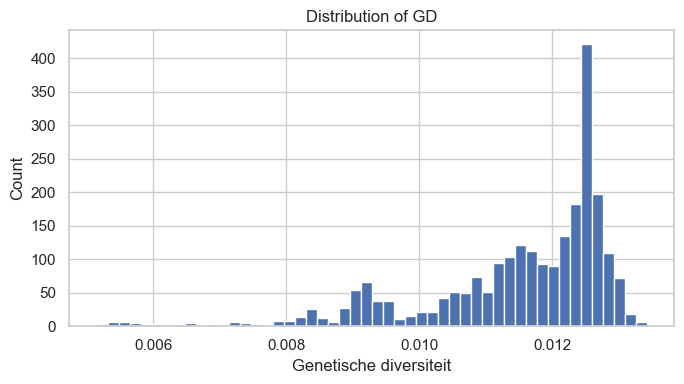

In [171]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(GD_SSP585_90_100["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

Kaart plotten

In [172]:
fig_GD_SSP585_90_100 = px.scatter_geo(
    GD_SSP585_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit volgens SSP585 (2090-2100)",
    range_color = (0, 0.017)
)

fig_GD_SSP585_90_100.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP585_90_100.show()

Kaart met verschil plotten

In [173]:
GD_SSP585_90_100["Relatief verschil"] = (GD_SSP585_90_100["GD"] - df_bio["co1_genetic_diversity_mean"])/df_bio["co1_genetic_diversity_mean"]
fig_GD_SSP585_90_100_verschil = px.scatter_geo(
    GD_SSP585_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil in genetische diversiteit (SSP585 (2090-2100) vs Huidige situatie)"
)

fig_GD_SSP585_90_100_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "GD"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_GD_SSP585_90_100_verschil.show()

C:\Users\katom\AppData\Local\Temp\ipykernel_14972\1423958052.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

